In [3]:
#!/usr/bin/env python3
import pandas as pd
import os

def main():
    print("=" * 60)
    print("BIORUN METADATA FILTERED EXTRACTION")
    print("=" * 60)
    
    # Dataset file (CSV רגיל)
    data_file = "sandpiper1.0.0.condensed.biorun-metadata.csv"
    if not os.path.exists(data_file):
        print(f"ERROR: File '{data_file}' not found!")
        return
    
    # Load dataset (CSV רגיל)
    try:
        df = pd.read_csv(data_file)  # אין compression
        print(f"✓ Dataset loaded successfully! Total rows: {len(df):,}")
    except Exception as e:
        print(f"ERROR loading dataset: {e}")
        return
    
    # Keep only required columns
    required_cols = ['run_accession', 'biosample', 'organism_name']
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        print(f"ERROR: Missing columns in dataset: {missing_cols}")
        return
    
    df = df[required_cols].copy()
    
    # Filter for 'metagenome' in organism_name
    df = df[df['organism_name'].str.contains('metagenome', case=False, na=False)]
    print(f"✓ Filtered rows containing 'metagenome': {len(df):,}")
    
    # Rename 'organism_name' to 'organism'
    df.rename(columns={'organism_name': 'organism'}, inplace=True)
    
    # Save filtered dataset
    output_file = "filtered_bioruns.csv"
    df.to_csv(output_file, index=False)
    print(f"✓ Filtered dataset saved to '{output_file}'")
    print("=" * 60)

if __name__ == "__main__":
    main()



BIORUN METADATA FILTERED EXTRACTION


<ipython-input-3-356877938452>:18: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_file)  # אין compression


✓ Dataset loaded successfully! Total rows: 700,708
✓ Filtered rows containing 'metagenome': 635,390
✓ Filtered dataset saved to 'filtered_bioruns.csv'


EDA ON FILTERED BIORUNS
Total filtered rows: 635,390
Unique biosamples: 571,359
Unique organisms: 316

Top 10 biosamples with most bioruns:
SAMEA5989477: 2076 bioruns
SAMN16925175: 442 bioruns
SAMN07507533: 396 bioruns
SAMN46555814: 322 bioruns
SAMN06233224: 277 bioruns
SAMN15699795: 162 bioruns
SAMN34719148: 158 bioruns
SAMN13782218: 147 bioruns
SAMN43778631: 124 bioruns
SAMN13241759: 116 bioruns
Average bioruns per biosample: 1.11
Max bioruns per biosample: 2076
Min bioruns per biosample: 1


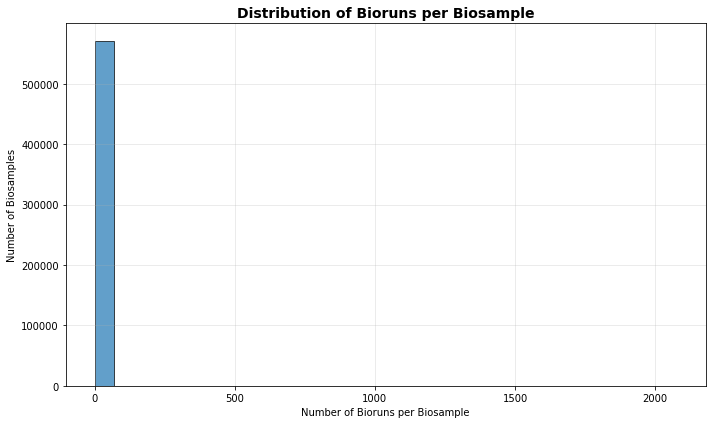


Top 10 organisms:
organism
human gut metagenome      185541
metagenome                 69417
gut metagenome             52803
soil metagenome            41909
human metagenome           29246
mouse gut metagenome       21199
feces metagenome           17553
marine metagenome          15783
wastewater metagenome      14005
human feces metagenome     12136
Name: count, dtype: int64


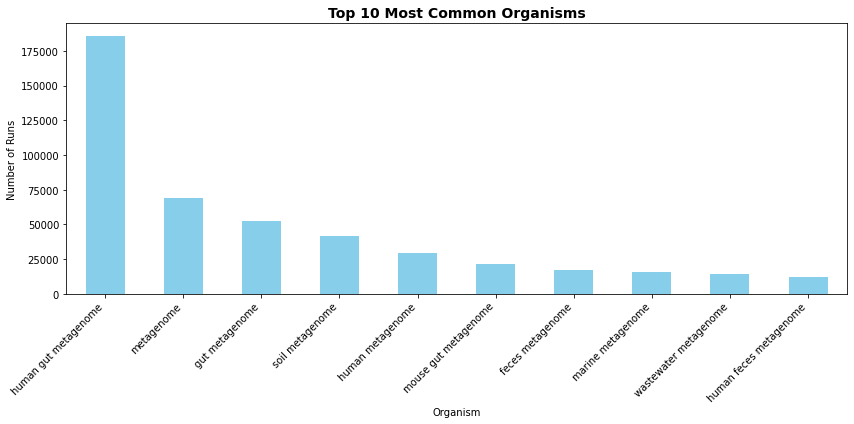

In [2]:
#!/usr/bin/env python3
import pandas as pd
import matplotlib.pyplot as plt
import os

def eda_bioruns(filtered_file: str = "filtered_bioruns.csv"):
    """Perform EDA on filtered bioruns dataset."""
    if not os.path.exists(filtered_file):
        raise FileNotFoundError(f"File '{filtered_file}' not found!")

    df = pd.read_csv(filtered_file)
    print("="*60)
    print("EDA ON FILTERED BIORUNS")
    print("="*60)
    print(f"Total filtered rows: {len(df):,}")
    print(f"Unique biosamples: {df['biosample'].nunique():,}")
    print(f"Unique organisms: {df['organism'].nunique():,}")

    # Bioruns per biosample
    bioruns_per_biosample = df.groupby('biosample').size()
    print("\nTop 10 biosamples with most bioruns:")
    top_bioruns = bioruns_per_biosample.sort_values(ascending=False).head(10)
    for biosample, count in top_bioruns.items():
        print(f"{biosample}: {count} bioruns")

    print(f"Average bioruns per biosample: {bioruns_per_biosample.mean():.2f}")
    print(f"Max bioruns per biosample: {bioruns_per_biosample.max()}")
    print(f"Min bioruns per biosample: {bioruns_per_biosample.min()}")

    # Distribution plot - Bioruns per biosample
    plt.figure(figsize=(10,6))
    plt.hist(bioruns_per_biosample, bins=30, edgecolor='black', alpha=0.7)
    plt.title('Distribution of Bioruns per Biosample', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Bioruns per Biosample')
    plt.ylabel('Number of Biosamples')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Top 10 organisms
    organism_counts = df['organism'].value_counts()
    top_organisms = organism_counts.head(10)
    print("\nTop 10 organisms:")
    print(top_organisms)

    # Bar chart - Top 10 organisms
    plt.figure(figsize=(12,6))
    top_organisms.plot(kind='bar', color='skyblue')
    plt.title('Top 10 Most Common Organisms', fontsize=14, fontweight='bold')
    plt.xlabel('Organism')
    plt.ylabel('Number of Runs')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    eda_bioruns()


In [27]:
#!/usr/bin/env python3
import pandas as pd
import os

def main():
    print("=" * 60)
    print("PREVIEW FIRST 100 COLUMNS FROM METADATA FILE")
    print("=" * 60)

    # קובץ המקור הדחוס
    data_file = "sandpiper1.0.0.condensed.biosample-metadata.csv.gz"
    if not os.path.exists(data_file):
        print(f"ERROR: File '{data_file}' not found!")
        return

    # טעינת הקובץ (רק את 100 העמודות הראשונות)
    try:
        # טוען רק את שמות העמודות
        all_columns = pd.read_csv(data_file, compression='gzip', nrows=0).columns.tolist()
        first_100_cols = all_columns[300:401]

        # טוען רק את 100 העמודות הראשונות
        df = pd.read_csv(data_file, compression='gzip', usecols=first_100_cols)
        print(f"✓ Loaded second 100 columns. Total rows: {len(df):,}")
    except Exception as e:
        print(f"ERROR loading dataset: {e}")
        return

    # הדפסת שמות העמודות
    print("\n🔍 First 100 column names:")
    for i, col in enumerate(first_100_cols, start=1):
        print(f"{i:3}. {col}")

    # הדפסת 5 שורות ראשונות מתוך העמודות האלה
    print("\n📄 Preview of first 5 rows from selected columns:")
    print(df.head().to_string(index=False))

    # --- שאר הקוד (סינון ושמירה) בהערה ---
    """
    # סינון לפי המילה 'soil' בתוך organism_name
    df_soil = df[df['organism_name'].str.contains('soil', case=False, na=False)]
    print(f"\n✓ Rows containing 'soil': {len(df_soil):,}")

    # שמירה לקובץ חדש
    output_file = "soil_only_organism_names.csv"
    df_soil.to_csv(output_file, index=False)
    print(f"✓ Filtered data saved to '{output_file}'")
    """

    print("=" * 60)

if __name__ == "__main__":
    main()


PREVIEW FIRST 100 COLUMNS FROM METADATA FILE


<ipython-input-27-866871deb826>:23: DtypeWarning: Columns (300,301,303,304,305,306,307,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,347,348,349,351,352,354,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,374,375,376,377,379,380,381,382,383,384,385,387,388,389,390,391,392,393,394,395,396,397,398,399,400) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_file, compression='gzip', usecols=first_100_cols)


✓ Loaded second 100 columns. Total rows: 432,380

🔍 First 100 column names:
  1. serotype
  2. gold_ecosystem_classification
  3. sample_day
  4. patient_id
  5. sample_source
  6. cemba_id
  7. location
  8. host_phenotype
  9. reads
 10. notes
 11. read
 12. water_temp
 13. host_color
 14. misc_param
 15. extreme_event
 16. drug_usage
 17. phase
 18. experiment
 19. component_organism
 20. description
 21. organism
 22. samp_store_dur
 23. samp_store_loc
 24. sample_title
 25. secondary_treatment
 26. seq_methods
 27. sewage_type
 28. wastewater_type
 29. geo-loc-name
 30. housing_temperature
 31. infection_status
 32. checklist_accession
 33. environmental_material_label
 34. last_update_date
 35. sample_protocol,_label
 36. sampling_campaign,_label
 37. sampling_campaign,_plateform
 38. sampling_campaign,_report
 39. sampling_event,_date-time,_start
 40. sampling_event,_date/time,_end
 41. sampling_event,_device_label
 42. sampling_event,_environment
 43. sampling_event,_label
 44.

In [ ]:
import pandas as pd
import os

def main():
    data_file = "sandpiper1.0.0.condensed.biosample-metadata.csv.gz"
    if not os.path.exists(data_file):
        print(f"ERROR: File '{data_file}' not found!")
        return

    target_column = "soil_type"

    try:
        df = pd.read_csv(data_file, compression='gzip', usecols=[target_column])

        df_filtered = df.dropna(subset=[target_column])

        print(f"\n📊 10 rows of column '{target_column}' without NaN values:")
        print(df_filtered[target_column].head(10).to_string(index=False))

    except ValueError:
        print(f"ERROR: Column '{target_column}' not found in the file.")
    except Exception as e:
        print(f"ERROR loading dataset: {e}")

if __name__ == "__main__":
    main()



📊 10 rows of column 'soil_type' without NaN values:
Eluviated dystric brunisol
Eluviated dystric brunisol
Eluviated dystric brunisol
Eluviated dystric brunisol
Eluviated dystric brunisol
Eluviated dystric brunisol
Eluviated dystric brunisol
Eluviated dystric brunisol
Eluviated dystric brunisol
Eluviated dystric brunisol


<ipython-input-32-5201f9235fc2>:15: DtypeWarning: Columns (572) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_file, compression='gzip', usecols=[target_column])


In [ ]:
import pandas as pd
import os

def main():
    data_file = "sandpiper1.0.0.condensed.biosample-metadata.csv.gz"
    if not os.path.exists(data_file):
        print(f"ERROR: File '{data_file}' not found!")
        return

    target_column = "collection_date"

    try:
        df = pd.read_csv(data_file, compression='gzip', usecols=[target_column])

        total_rows = len(df)

        non_empty_rows = df[target_column].count()

        print(f"\n📊 Summary for column '{target_column}':")
        print(f"Total rows in column: {total_rows}")
        print(f"Non-empty rows in column: {non_empty_rows}")

        df_filtered = df.dropna(subset=[target_column])

        print(f"\n📊 First 10 rows of column '{target_column}' without NaN values:")
        print(df_filtered[target_column].head(10).to_string(index=False))

    except ValueError:
        print(f"ERROR: Column '{target_column}' not found in the file.")
    except Exception as e:
        print(f"ERROR loading dataset: {e}")

if __name__ == "__main__":
    main()


📊 Summary for column 'env_biome':
Total rows in column: 432380
Non-empty rows in column: 29046

📊 First 10 rows of column 'env_biome' without NaN values:
                       city
                       city
                       city
                       city
                       city
             not applicable
                       city
                       city
mammalia-associated habitat
mammalia-associated habitat


<ipython-input-52-38ac226820e4>:15: DtypeWarning: Columns (121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_file, compression='gzip', usecols=[target_column])


In [62]:
import pandas as pd
import os

def main():
    data_file = "sandpiper1.0.0.condensed.biosample-metadata.csv.gz"
    
    if not os.path.exists(data_file):
        print(f"ERROR: File '{data_file}' not found!")
        return

    # Number of rows to sample from the file
    sample_rows = 10000

    try:
        # Read a sample of the file
        print(f"Loading first {sample_rows} rows from the file...")
        # Note: The DtypeWarning can be ignored for this specific task
        df_sample = pd.read_csv(data_file, compression='gzip', nrows=sample_rows, low_memory=False)

        # Create a dictionary to hold the non-null count for each column
        non_null_counts = {}
        for column in df_sample.columns:
            non_null_counts[column] = df_sample[column].count()

        # Convert the dictionary to a DataFrame for easy sorting
        counts_df = pd.DataFrame(non_null_counts.items(), columns=['Column', 'Non-Null Count'])

        # Sort the columns by non-null count in descending order
        sorted_counts = counts_df.sort_values(by='Non-Null Count', ascending=False)
        
        # Select the top 10 columns
        top_10_columns = sorted_counts.head(5000)
        
        print("\n📊 Top 10 columns by number of non-null values (based on a 5000-row sample):")
        print(top_10_columns.to_string(index=False))

    except Exception as e:
        print(f"ERROR loading dataset: {e}")

if __name__ == "__main__":
    main()

Loading first 10000 rows from the file...

📊 Top 10 columns by number of non-null values (based on a 5000-row sample):
                                                                                                                                 Column  Non-Null Count
                                                                                                                              biosample           10000
                                                                                                                        collection_date            8247
                                                                                                                           geo_loc_name            7849
                                                                                                                                lat_lon            7542
                                                                                                                         

In [53]:
import pandas as pd
import os

def main():
    source_file = "sandpiper1.0.0.condensed.biosample-metadata.csv.gz"
    output_file = "relevant_columns_data.csv.gz"

    if not os.path.exists(source_file):
        print(f"ERROR: File '{source_file}' not found!")
        return

    # רשימת העמודות שאתה רוצה לחלץ
    columns_to_extract = [
        "collection_date",
        "geo_loc_name",
        "lat_lon",
        "isolation_source",
        "host"
    ]

    try:
        print(f"Loading only the specified columns from '{source_file}'...")
        
        # טוען את הקובץ המקורי עם העמודות שבחרת בלבד
        # השימוש ב-usecols גורם לפאנדס לטעון רק את העמודות האלה,
        # מה שחוסך המון זיכרון וזמן
        df_selected = pd.read_csv(source_file, 
                                  compression='gzip', 
                                  usecols=columns_to_extract)
        
        print("Done loading. Saving the data to a new file...")

        # שומר את הנתונים החדשים לקובץ Gzip חדש
        df_selected.to_csv(output_file, compression='gzip', index=False)

        print(f"✅ Success! The new file '{output_file}' has been created.")
        print(f"It contains {df_selected.shape[0]} rows and {df_selected.shape[1]} columns.")

    except ValueError:
        print(f"ERROR: One or more of the specified columns were not found in the file.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

if __name__ == "__main__":
    main()

Loading only the specified columns from 'sandpiper1.0.0.condensed.biosample-metadata.csv.gz'...


<ipython-input-53-de1f5a5095e7>:27: DtypeWarning: Columns (9,10,35,108,168) have mixed types. Specify dtype option on import or set low_memory=False.
  df_selected = pd.read_csv(source_file,


Done loading. Saving the data to a new file...
✅ Success! The new file 'relevant_columns_data.csv.gz' has been created.
It contains 432380 rows and 5 columns.
